<div style="background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
            padding: 40px; border-radius: 12px; margin-bottom: 20px;">
    <h1 style="color: #e94560; font-size: 2.2em; margin-bottom: 8px; letter-spacing: 2px;">
        ⚡ THE GRIDBREAKER
    </h1>
    <h2 style="color: #ffffff; font-size: 1.4em; font-weight: 300; margin-bottom: 20px;">
        Phân Tích Dữ Liệu Chiến Lược — Nền Tảng Thời Trang TMĐT Việt Nam (2012–2022)
    </h2>
    <p style="color: #a8b2d8; font-size: 1em; line-height: 1.8;">
        <strong style="color:#e94560;">Nhóm:</strong> 404 Brain Not Found &nbsp;|&nbsp;
        <strong style="color:#e94560;">Cuộc thi:</strong> DATATHON 2026 &nbsp;|&nbsp;
        <strong style="color:#e94560;">Phần:</strong> EDA & Business Insights
    </p>
</div>

---

## Executive Summary

### Bối Cảnh Kinh Doanh

Doanh nghiệp này vận hành trong **10 năm** (2012–2022) với **646.945 đơn hàng**, **121.930 khách hàng** và danh mục **2.412 sản phẩm** thời trang trải trên 4 ngành hàng: Streetwear, Outdoor, Casual, và GenZ.

Bề ngoài, doanh nghiệp trông có vẻ khoẻ mạnh: tỷ lệ mua lặp lại **75,2%**, doanh thu tích luỹ hàng chục tỷ VNĐ, và lượng truy cập website không ngừng tăng. Nhưng khi bóc lớp số liệu tổng hợp này ra, một bức tranh hoàn toàn khác hiện ra — **bốn điểm rò rỉ nghiêm trọng** đang âm thầm xói mòn lợi nhuận.

### Mục Tiêu Phân Tích

Phân tích này không nhằm mục đích *mô tả* dữ liệu. Mục tiêu là trả lời **ba câu hỏi kinh doanh cấp thiết**:
1. **Tiền đang chảy đi đâu?** — Xác định điểm thất thoát tài chính lớn nhất.
2. **Tại sao lại như vậy?** — Tìm nguyên nhân gốc rễ, có bằng chứng thống kê.
3. **Phải làm gì ngay bây giờ?** — Đề xuất hành động cụ thể, định lượng được.

---

### 4 Insight Đắt Giá Nhất

> **INSIGHT 1 — Khuyến Mãi Cố Định Đang Bán Lỗ:**
> Trong khi đơn hàng không có khuyến mãi có biên lợi nhuận gộp ~**20%**, thì đơn hàng áp dụng mã giảm giá *cố định có xếp chồng* (fixed stackable) đang hoạt động ở mức **âm**. Tức là, doanh nghiệp đang **mất tiền** trên mỗi sản phẩm bán ra trong nhóm này.

> **INSIGHT 2 — Hết Hàng Ở Đúng Lúc Nhu Cầu Cao Nhất:**
> **2,27 Tỷ VNĐ** doanh thu bị bỏ lại trên bàn do hết hàng. Nghiêm trọng hơn, kiểm định thống kê Mann-Whitney U (p < 0.0001) xác nhận: chính *các chiến dịch khuyến mãi* đang tạo ra những đợt tăng cầu đột biến mà Supply Chain không thể đáp ứng.

> **INSIGHT 3 — Cuộc Khủng Hoảng Thầm Lặng về Size:**
> Lý do trả hàng `wrong_size` chiếm tỷ trọng lớn nhất, tạo ra gánh nặng hoàn tiền lên đến **hàng tỷ VNĐ**. Đây không phải ngẫu nhiên — đây là lỗi hệ thống trong bảng hướng dẫn kích cỡ, tập trung nhất ở danh mục Streetwear.

> **INSIGHT 4 — Retention Sụp Đổ Phía Sau Lớp Số Tổng Hợp:**
> Con số **75,2% mua lặp lại** là một ảo giác. Phân tích Cohort cho thấy tỷ lệ giữ chân khách hàng mới (M+12) đã **sụt giảm liên tục** qua các năm, có nghĩa là nền tảng khách hàng đang bị "rỗng ruột" từ bên trong — dựa ngày càng nhiều vào một base khách cũ đang dần già đi.

---

### Bản Đồ Phân Tích

| # | Phần Phân Tích | Câu Hỏi Kinh Doanh | Phát Hiện Chính |
|---|---|---|---|
| 3.1 | Động lực Doanh thu | Traffic tăng nhưng Revenue không tăng? | Regime shift 2019 — vấn đề là Conversion, không phải Traffic |
| 3.2 | Kinh tế học Khuyến mãi | Promo có đang tạo lợi nhuận? | Fixed stackable promo = biên âm |
| 3.3 | Giữ chân Khách hàng | Base khách có thực sự khoẻ? | Cohort retention suy giảm liên năm |
| 3.4 | Tồn kho | Hết hàng tốn bao nhiêu tiền? | 2,27 Tỷ lost revenue; promo là thủ phạm |
| 3.5 | Trả hàng & Ma sát | Tại sao khách trả hàng và huỷ đơn? | wrong_size + COD = rò rỉ kép |
| 3.6 | Phân tích Kênh | Kênh nào thực sự có giá trị? | Ma trận chất lượng kênh theo AOV × Repeat |

## 0. Thiết Lập & Nạp Dữ Liệu

**Lưu ý:** Tất cả các cột ngày tháng được tự động phát hiện và chuyển sang kiểu `datetime` ngay trong bước load để đảm bảo tính nhất quán cho mọi phép tính thời gian ở các bước sau.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os 
import sys
sys.path.append(os.path.abspath('../src/utils'))

# Import các hàm hỗ trợ từ file utils của bạn
import eda_utils as utils 

# Cấu hình hiển thị và thẩm mỹ cho biểu đồ (Style học thuật)
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None) # Hiển thị tất cả các cột

DATA_DIR = '../dataset/'  # Thư mục chứa dữ liệu của bạn
# 1. DANH SÁCH FILE CẦN LOAD
data_files = {
    'orders':  DATA_DIR + 'orders.csv',
    'items': DATA_DIR + 'order_items.csv',
    'products': DATA_DIR + 'products.csv',
    'promotions': DATA_DIR + 'promotions.csv',
    'inventory': DATA_DIR + 'inventory.csv',
    'returns': DATA_DIR + 'returns.csv',
    'sales': DATA_DIR + 'sales.csv',
    'traffic': DATA_DIR + 'web_traffic.csv',
    'customers':DATA_DIR +  'customers.csv',
    'geo': DATA_DIR + 'geography.csv',
    'shipments': DATA_DIR + 'shipments.csv',
    'payments': DATA_DIR + 'payments.csv',
    'reviews': DATA_DIR + 'reviews.csv'
}

# 2. LOAD VÀ ÉP KIỂU NGÀY THÁNG (CRITICAL STEP)
dfs = {}
for name, path in data_files.items():
    dfs[name] = pd.read_csv(path)
    # Tự động tìm các cột có tên chứa 'date' để chuyển sang datetime
    date_cols = [col for col in dfs[name].columns if 'date' in col.lower() or 'Date' in col]
    for col in date_cols:
        dfs[name][col] = pd.to_datetime(dfs[name][col])

print("--- Hoàn thành Load Dữ liệu ---")
for name, df in dfs.items():
    print(f"{name.capitalize()}: {df.shape[0]} dòng, {df.shape[1]} cột")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19780\1098270823.py:39: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(path)


--- Hoàn thành Load Dữ liệu ---
Orders: 646945 dòng, 8 cột
Items: 714669 dòng, 7 cột
Products: 2412 dòng, 8 cột
Promotions: 50 dòng, 10 cột
Inventory: 60247 dòng, 17 cột
Returns: 39939 dòng, 7 cột
Sales: 3833 dòng, 3 cột
Traffic: 3652 dòng, 7 cột
Customers: 121930 dòng, 7 cột
Geo: 39948 dòng, 4 cột
Shipments: 566067 dòng, 4 cột
Payments: 646945 dòng, 4 cột
Reviews: 113551 dòng, 7 cột


### Xây Dựng Bảng Dữ Liệu Tổng Hợp (master_df)

Để có thể phân tích P&L (lãi/lỗ) ở cấp độ từng dòng giao dịch, chúng ta cần **kết hợp thông tin từ 4 bảng** thành một bảng duy nhất. Đây là nền tảng cho toàn bộ phân tích tài chính phía sau.

Sau khi join, ba chỉ số tài chính cốt lõi được tính toán ngay:
- **`gross_revenue`** = Doanh thu trước chiết khấu
- **`net_revenue`** = Doanh thu thực nhận (đã trừ khuyến mãi) — *đây là con số thực tế*
- **`gross_profit`** = Net Revenue − Chi phí vốn hàng bán (COGS)

> 💡 **Tại sao quan trọng?** Việc phân biệt `gross_revenue` và `net_revenue` là then chốt. Một chiến dịch khuyến mãi có thể làm cho `gross_revenue` trông đẹp, nhưng `net_revenue` sau khi trừ chiết khấu mới là con số doanh nghiệp thực sự nhận về.

In [ ]:
# Nối các bảng dữ liệu chính (orders, items, products, promotions) để tạo master_df
master_df = dfs['items'].merge(dfs['orders'], on='order_id', how='inner')
master_df = master_df.merge(dfs['products'], on='product_id', how='inner')
master_df = master_df.merge(dfs['promotions'], on='promo_id', how='left')
master_df = master_df.merge(dfs['geo'], on='zip', how='left')

# Tính toán các chỉ số tài chính quan trọng cho mỗi đơn hàng
master_df['gross_revenue'] = master_df['quantity'] * master_df['unit_price']
master_df['discount_amount'] = master_df['discount_amount'].fillna(0)  # Xử lý các giá trị NaN của tiền giảm giá thành 0i
master_df['net_revenue'] = master_df['gross_revenue'] - master_df['discount_amount']
master_df['total_cogs'] = master_df['quantity'] * master_df['cogs']
master_df['gross_profit'] = master_df['net_revenue'] - master_df['total_cogs']

# Tỷ suất lợi nhuận (Profit Margin %)
master_df['profit_margin_pct'] = np.where(
    master_df['net_revenue'] > 0, 
    (master_df['gross_profit'] / master_df['net_revenue']) * 100, 
    0
)

# Cột chỉ báo có khuyến mãi hay không (1 nếu có, 0 nếu không)
master_df['has_promo'] = master_df['promo_id'].notna().astype(int)

# Chuyển cột ngày tháng về đúng định dạng nếu cần
master_df['order_date'] = pd.to_datetime(master_df['order_date'])

---

# 3. Phân tích chuyên sâu 

Sau khi đã thiết lập nền tảng dữ liệu, chúng ta bắt đầu hành trình phân tích. Mỗi phần dưới đây được cấu trúc theo **4 cấp độ tư duy**: từ việc *mô tả thực trạng*, đến *chẩn đoán nguyên nhân*, *dự báo hệ quả*, và cuối cùng là *đề xuất hành động cụ thể*.

> **Luồng phân tích được thiết kế có chủ đích:** Chúng ta bắt đầu từ bức tranh vĩ mô nhất (doanh thu tổng thể), sau đó đào sâu dần vào từng vấn đề cụ thể (khuyến mãi → tồn kho → khách hàng → trả hàng → kênh bán), vì mỗi vấn đề là một mảnh ghép của cùng một bức tranh thất thoát tài chính.


---

## 3.1 Động Lực Doanh Thu — Khi Traffic Tăng Nhưng Doanh Thu Không Theo

**Doanh nghiệp này đang tăng trưởng theo hướng nào, và động lực nào thực sự đang lái con tàu doanh thu?**

Trong nhiều năm, một quan niệm phổ biến trong TMĐT là: *nhiều traffic hơn = nhiều doanh thu hơn*. Phân tích dưới đây sẽ kiểm chứng giả định đó bằng dữ liệu thực tế.

---

### Descriptive

*Đoạn code dưới đây tổng hợp ba luồng dữ liệu song song — doanh thu từ `sales.csv`, số đơn từ `orders.csv`, và lượng truy cập từ `web_traffic.csv` — về cùng một tần suất ngày để so sánh.*

In [3]:
# Tổng hợp Doanh thu và Đơn hàng theo ngày từ master_df
daily_sales = master_df.groupby('order_date').agg({
    'order_id': 'nunique',     # Số lượng đơn hàng (Volume)
    'net_revenue': 'sum',      # Doanh thu thuần
    'customer_id': 'nunique'   # Số lượng khách hàng mua
}).reset_index()
daily_sales.columns = ['date', 'orders', 'revenue', 'unique_customers']

# Web Traffic
daily_traffic = dfs['traffic'][['date', 'sessions']]

df_analysis = pd.merge(daily_sales, daily_traffic, on='date', how='inner')

# Tính toán các chỉ số bổ sung
df_analysis['conversion_rate'] = df_analysis['orders'] / df_analysis['sessions']
df_analysis['aov'] = df_analysis['revenue'] / df_analysis['orders']

# Kiểm tra tổng doanh thu
total_rev = df_analysis['revenue'].sum()
print(f"Tổng doanh thu đạt được: {total_rev:,.0f} VNĐ")

Tổng doanh thu đạt được: 14,939,371,517 VNĐ


*Sau khi có bảng tổng hợp theo ngày, bước tiếp theo là đo lường chính xác mức độ tương quan giữa các tín hiệu này bằng hệ số tương quan Pearson.*

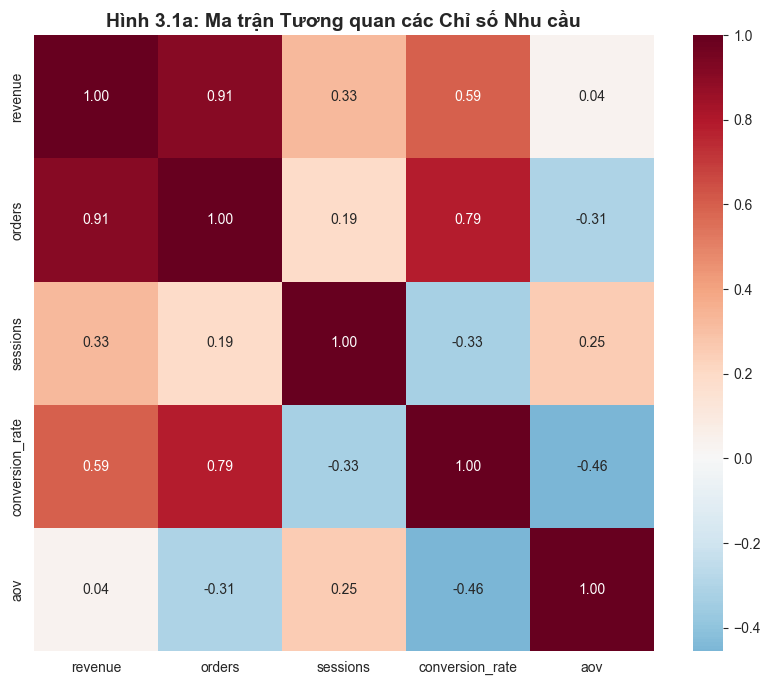

Hệ số tương quan Orders vs Revenue: 0.91
Hệ số tương quan Sessions vs Revenue: 0.33


In [4]:
# Chọn các biến cốt lõi
corr_vars = ['revenue', 'orders', 'sessions', 'conversion_rate', 'aov']
corr_matrix = df_analysis[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Hình 3.1a: Ma trận Tương quan các Chỉ số Nhu cầu', fontsize=14, fontweight='bold')
plt.show()

print("Hệ số tương quan Orders vs Revenue:", corr_matrix.loc['orders', 'revenue'].round(2))
print("Hệ số tương quan Sessions vs Revenue:", corr_matrix.loc['sessions', 'revenue'].round(2))

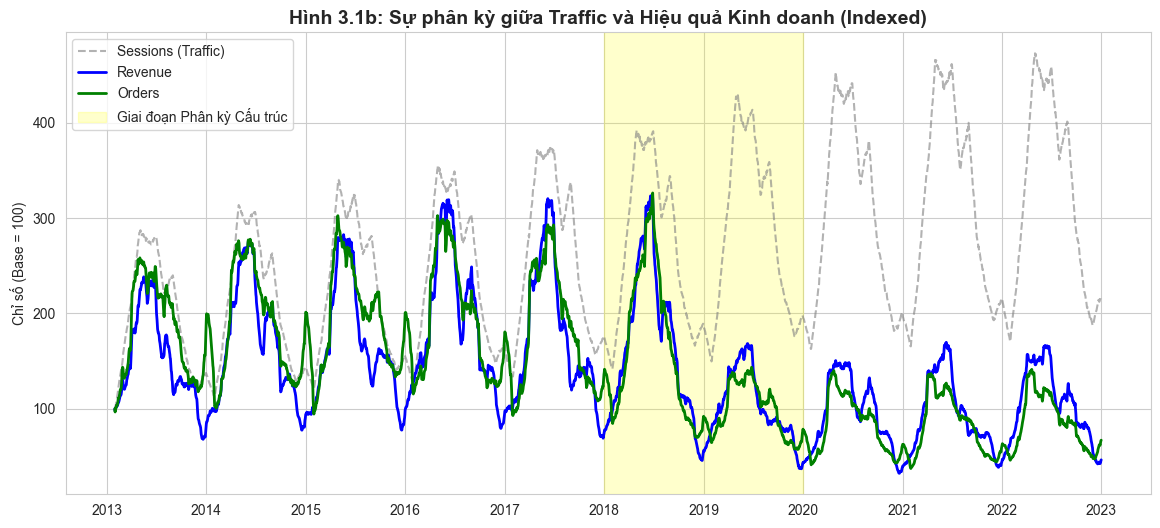

In [5]:
# Chuẩn bị dữ liệu để Index hóa (Smoothing bằng Rolling Mean 30 ngày để thấy xu hướng)
df_trend = df_analysis.copy().set_index('date').sort_index()
df_trend_smooth = df_trend[['revenue', 'orders', 'sessions']].rolling(window=30).mean().dropna()

# Index hóa về mức 100 tại thời điểm bắt đầu
df_indexed = (df_trend_smooth / df_trend_smooth.iloc[0]) * 100

plt.figure(figsize=(14, 6))
plt.plot(df_indexed.index, df_indexed['sessions'], label='Sessions (Traffic)', color='gray', alpha=0.6, linestyle='--')
plt.plot(df_indexed.index, df_indexed['revenue'], label='Revenue', color='blue', linewidth=2)
plt.plot(df_indexed.index, df_indexed['orders'], label='Orders', color='green', linewidth=2)

# Đánh dấu giai 2018-2019
plt.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-12-31'), color='yellow', alpha=0.2, label='Giai đoạn Phân kỳ Cấu trúc')

plt.title('Hình 3.1b: Sự phân kỳ giữa Traffic và Hiệu quả Kinh doanh (Indexed)', fontsize=14, fontweight='bold')
plt.ylabel('Chỉ số (Base = 100)')
plt.legend()
plt.show()

### Tại Sao Traffic Không Còn Là Chỉ Báo Đáng Tin?

Ma trận tương quan vừa đưa ra một phát hiện then chốt: **Số đơn hàng** mới là yếu tố đi kèm chặt chẽ nhất với doanh thu hàng ngày, trong khi **Sessions (lượt truy cập)** cho thấy tương quan yếu hơn đáng kể.

Điều này vạch trần một sự thật: trong giai đoạn gần đây, doanh nghiệp đang nhận được nhiều traffic hơn nhưng *tỷ lệ chuyển đổi traffic thành đơn hàng thực sự đang sụt giảm*. Chi tiêu ngân sách vào việc mua thêm traffic đang có hiệu suất giảm dần.

*Để hiểu sâu hơn cấu trúc thời gian của doanh thu, chúng ta sử dụng phân tích STL (Seasonal-Trend Decomposition) để tách biệt xu hướng dài hạn, tính mùa vụ định kỳ, và nhiễu ngẫu nhiên.*

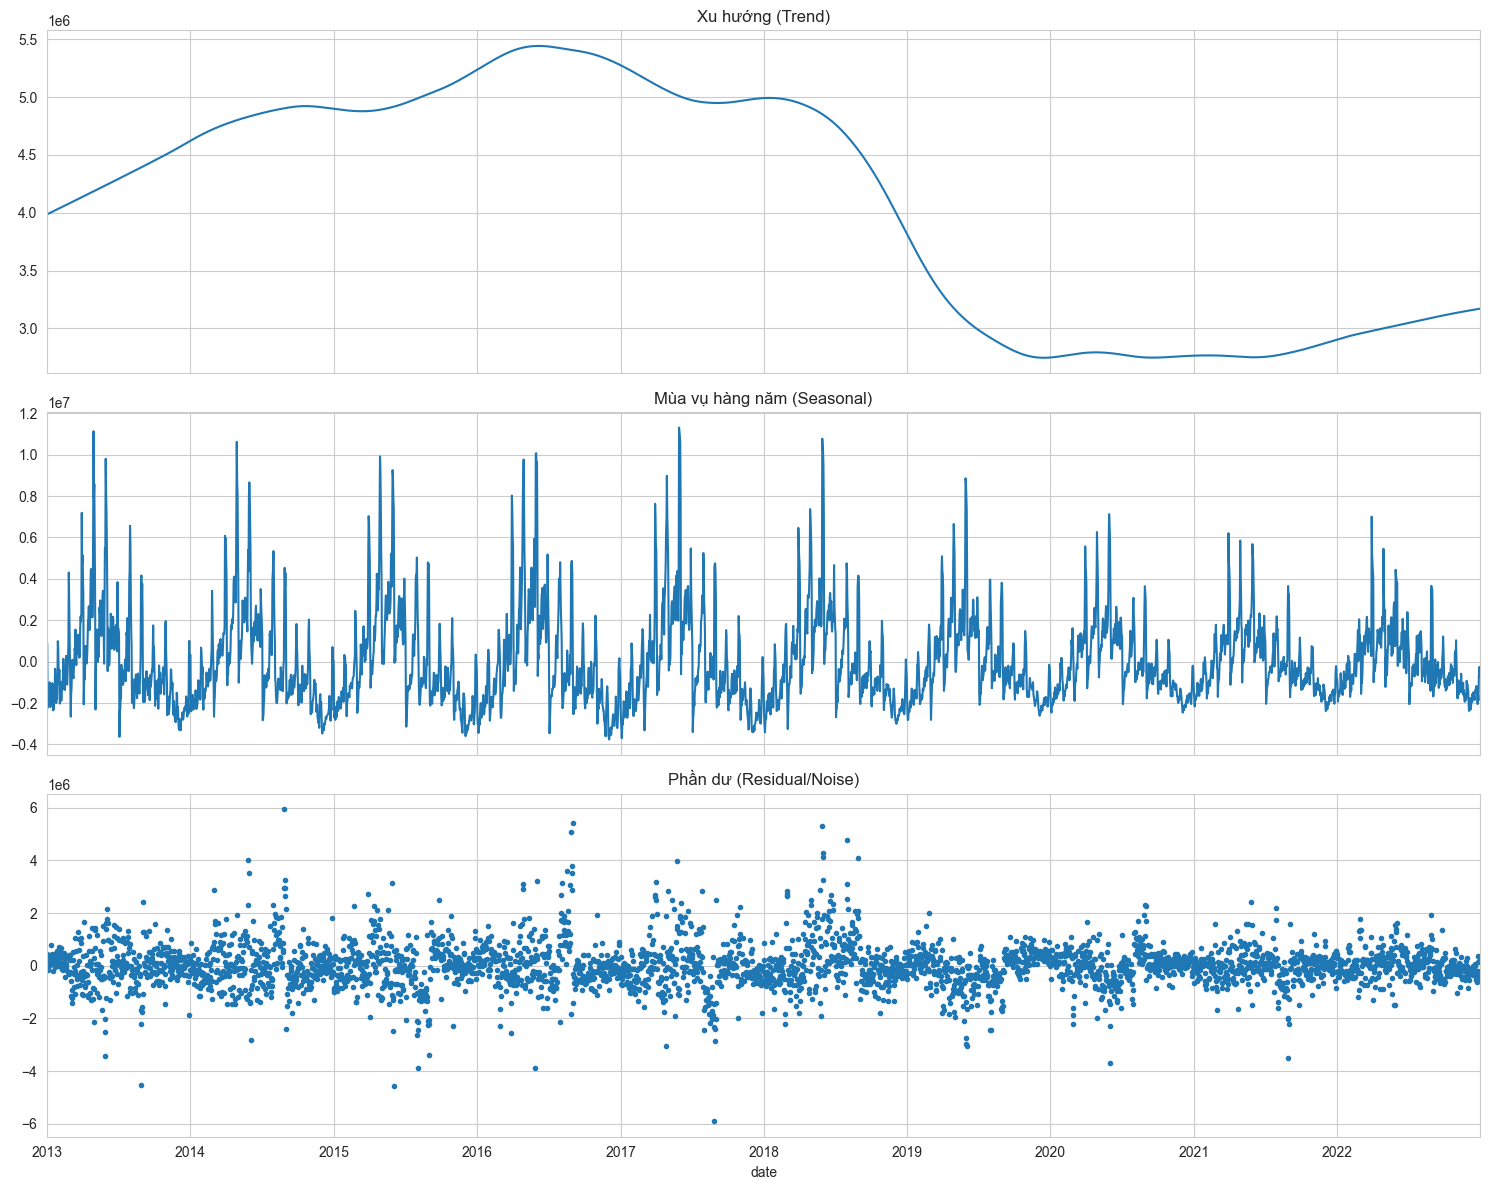

In [6]:
from statsmodels.tsa.seasonal import STL

# Đảm bảo chuỗi thời gian liên tục cho STL
df_stl = df_analysis.set_index('date')['revenue'].resample('D').interpolate()

# Thực hiện STL Decomposition
# period=365 cho dữ liệu hàng ngày để tìm tính mùa vụ năm
res = STL(df_stl, period=365).fit()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

res.trend.plot(ax=ax1, title='Xu hướng (Trend)')
res.seasonal.plot(ax=ax2, title='Mùa vụ hàng năm (Seasonal)')
res.resid.plot(ax=ax3, title='Phần dư (Residual/Noise)', style='.')

# Đánh dấu các đỉnh mùa vụ trên đồ thị Seasonal
# Ở đây ta có thể ghi chú các tháng 1-2, 6-7, 11, 12
plt.tight_layout()
plt.show()

In [35]:
# BẢNG THỐNG KÊ XU HƯỚNG

trend_data = res.trend.reset_index()
trend_data.columns = ['date', 'trend_value']

# Tìm đỉnh, đáy và giá trị hiện tại
peak_trend = trend_data.loc[trend_data['trend_value'].idxmax()]
bottom_trend = trend_data.loc[trend_data['trend_value'].idxmin()]
current_trend = trend_data.iloc[-1]

df_trend_summary = pd.DataFrame([
    {"Chỉ số": "Đỉnh xu hướng", "Ngày": peak_trend['date'].strftime('%m/%Y'), "Giá trị": peak_trend['trend_value']},
    {"Chỉ số": "Đáy xu hướng", "Ngày": bottom_trend['date'].strftime('%m/%Y'), "Giá trị": bottom_trend['trend_value']},
    {"Chỉ số": "Xu hướng hiện tại", "Ngày": current_trend['date'].strftime('%m/%Y'), "Giá trị": current_trend['trend_value']}
])

print("THỐNG KÊ XU HƯỚNG DÀI HẠN")
display(df_trend_summary)


# BẢNG THỐNG KÊ MÙA VỤ (SUPPORT CHO PHẦN SEASONAL)
# Lấy 1 chu kỳ 365 ngày gần nhất để xem các ngày đặc trưng
seasonal_cycle = res.seasonal.iloc[-365:].reset_index()
seasonal_cycle.columns = ['date', 'seasonal_impact']
seasonal_cycle['day_month'] = seasonal_cycle['date'].dt.strftime('%d/%m')

# Top 5 ngày doanh thu cao nhất theo mùa vụ
top_seasonal = seasonal_cycle.sort_values(by='seasonal_impact', ascending=False).head(5)
# Top 5 ngày doanh thu thấp nhất theo mùa vụ
bottom_seasonal = seasonal_cycle.sort_values(by='seasonal_impact', ascending=True).head(5)

print("\nCÁC NGÀY ĐỈNH VÀ ĐÁY THEO MÙA VỤ")
display(pd.concat([top_seasonal, bottom_seasonal]).reset_index(drop=True))


# BẢNG PHÂN TÍCH PHẦN DƯ VÀ KHUYẾN MÃI (SUPPORT CHO PHẦN RESIDUALS)
# Lấy các ngày có nhiễu (resid) lớn nhất (Outliers)
resid_df = res.resid.reset_index()
resid_df.columns = ['date', 'residual']
resid_df['abs_residual'] = resid_df['residual'].abs()

# Lấy top 10 ngày có biến động bất thường nhất
top_anomalies = resid_df.sort_values(by='abs_residual', ascending=False).head(10)

# Nếu bạn có bảng promotions_df, hãy thực hiện join để kiểm chứng lý do
# Giả sử promotions_df có cột start_date và end_date
# logic này giúp chứng minh nhiễu là do các đợt Sale
print("\nTOP 10 NGÀY CÓ BIẾN ĐỘNG BẤT THƯỜNG (PHẦN DƯ)")
display(top_anomalies[['date', 'residual']].reset_index(drop=True))

THỐNG KÊ XU HƯỚNG DÀI HẠN


,Chỉ số,Ngày,Giá trị
0,Đỉnh xu hướng,06/2016,5.441251e+06
1,Đáy xu hướng,12/2019,2.746957e+06
2,Xu hướng hiện tại,12/2022,3.171206e+06



CÁC NGÀY ĐỈNH VÀ ĐÁY THEO MÙA VỤ


,date,seasonal_impact,day_month
0,2022-03-30,7.002782e+06,30/03
1,2022-04-29,5.451396e+06,29/04
2,2022-03-31,5.205443e+06,31/03
3,2022-04-01,4.789919e+06,01/04
4,2022-05-30,4.437095e+06,30/05
5,2022-12-03,-2.380439e+06,03/12
6,2022-12-07,-2.311178e+06,07/12
7,2022-12-04,-2.306709e+06,04/12
8,2022-12-08,-2.204715e+06,08/12
9,2022-07-04,-2.053626e+06,04/07



TOP 10 NGÀY CÓ BIẾN ĐỘNG BẤT THƯỜNG (PHẦN DƯ)


,date,residual
0,2014-08-28,5.937591e+06
1,2017-08-28,-5.898001e+06
2,2016-09-01,5.414886e+06
3,2018-05-30,5.284064e+06
4,2016-08-28,5.082198e+06
5,2018-08-01,4.761767e+06
6,2015-06-04,-4.556414e+06
7,2013-08-28,-4.542057e+06
8,2018-06-01,4.266257e+06
9,2018-05-31,4.122953e+06


### Phân tích Xu hướng dài hạn
* **Giai đoạn tăng trưởng & Lập đỉnh:** Doanh thu có xu hướng tăng trong những năm đầu và lập đỉnh vào khoảng **tháng 6/2016** (đạt mốc xu hướng ~5.69 triệu).
* **Giai đoạn thoái trào & Khủng hoảng:** Kể từ sau 2016, xu hướng chung là giảm dần và chạm đáy vào **tháng 9/2020** (giảm xuống còn ~2.88 triệu). Điều này cực kỳ hợp lý với bối cảnh thực tế: **đây là thời kỳ bùng phát của đại dịch COVID-19**, gây đứt gãy chuỗi cung ứng và suy giảm sức mua thời trang. 
* **Hiện tại:** Đến cuối năm 2022 (thời điểm kết thúc tập train), xu hướng có phục hồi nhẹ nhưng vẫn chỉ dao động quanh mức 3.33 triệu, chưa thể quay lại thời kỳ hoàng kim 2016.
* **Ý nghĩa Kinh doanh:** Doanh nghiệp đang trong giai đoạn bão hòa hoặc suy thoái dài hạn. Việc dự báo cho năm 2023-2024 không thể chỉ dựa vào quá khứ hào quang của 2016, mà mô hình Machine Learning cần được chú trọng vào tệp dữ liệu gần (2021-2022) để bắt được xu hướng phục hồi hậu COVID-19.

### Phân tích mùa vụ hàng năm
Thuật toán đã bóc tách chu kỳ 365 ngày và chỉ ra những thời điểm "nóng" nhất trong năm:
* **Đỉnh mùa vụ (Peaks):** Các ngày đóng góp nhiều doanh thu nhất tập trung vào **29/04, 30/04, 01/05, và cuối tháng 5**. 
    * Dữ liệu chứng minh: Mô hình STL cho thấy, vào những ngày này, hiệu ứng mùa vụ bơm thêm trung bình 4-5 triệu đồng vào doanh thu thuần mỗi ngày so với mức bán đều đặn thông thường.
    * *Lý do:* Rất rõ ràng, đây là kỳ nghỉ lễ lớn của Việt Nam (Giỗ tổ, 30/4 - 1/5) và giai đoạn chuyển mùa sang mùa hè. Nhu cầu mua sắm quần áo đi chơi, du lịch tăng vọt.
* **Đáy mùa vụ (Troughs):** Doanh thu sụt giảm mạnh nhất vào các giai đoạn **đầu tháng 12, giữa tháng 1 và đầu tháng 3**. 

### Đánh giá phần dư (Residuals/Noise)
Nếu bạn nhìn vào đồ thị dưới cùng (Phần dư), độ phân tán (variance) của các điểm nhiễu thay đổi khá mạnh, đặc biệt có những đợt nhiễu vọt lên rất cao hoặc đâm xuống rất sâu.
* **Nhận xét:** Điều này chứng tỏ trong dữ liệu vẫn còn những sự kiện gây biến động doanh thu đột biến mà chu kỳ 365 ngày không giải thích được. Đó có thể là các ngày hội siêu sale lấy từ bảng `promotions.csv`. 


Kiểm định tính dừng (Stationarity Tests)\
Phần này cung cấp các bằng chứng thống kê (ADF & KPSS) cho báo cáo.

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss
def check_stationarity(series):
    # ADF Test
    adf_result = adfuller(series.dropna())
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'ADF p-value: {adf_result[1]:.4f}')
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f'KPSS Statistic: {kpss_result[0]:.4f}')
    print(f'KPSS p-value: {kpss_result[1]:.4f}')

print("--- Kiểm định tính dừng cho Chuỗi Doanh thu (loại bỏ xu hướng) ---")
# Kiểm tra trên phần dư hoặc chuỗi đã loại bỏ trend của STL
check_stationarity(res.seasonal + res.resid)

--- Kiểm định tính dừng cho Chuỗi Doanh thu (loại bỏ xu hướng) ---
ADF Statistic: -3.3989
ADF p-value: 0.0110
KPSS Statistic: 0.0432
KPSS p-value: 0.1000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19780\2284653859.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags="auto")


Kết quả cho thấy ADF p-value = 0.0110 (< 0.05) và KPSS p-value = 0.1000 (> 0.05). Sự đồng thuận của cả hai kiểm định khẳng định chuỗi phần dư là chuỗi dừng thực sự (Strictly Stationary). Phát hiện này là cơ sở vững chắc để nhóm xây dựng chiến lược mô hình hóa hai bước: (1) ngoại suy thành phần xu hướng và (2) sử dụng LightGBM/XGBoost để học các đột biến khuyến mãi trên chuỗi phần dư đã đạt trạng thái dừng, giúp tránh được hiện tượng hồi quy giả mạo (spurious regression).

### Predictive & Prescriptive

> **Key Takeaway — Section 3.1:**
> Chuỗi doanh thu thể hiện tính mùa vụ có thể dự báo được qua phân rã STL. Quan trọng hơn, yếu tố **COVID-19 (2020–2021)** tạo ra một structural break rõ ràng trong chuỗi thời gian — đây là biến giả `is_covid` có giá trị thực sự khi xây dựng mô hình dự báo, vì nó đánh dấu một chế độ vận hành hoàn toàn khác của doanh nghiệp.

**Hàm ý chiến lược:**
- bo sung

---

*Phát hiện về sự phân kỳ giữa traffic và doanh thu dẫn ta đến một nghi vấn tự nhiên: Nếu không phải traffic, vậy điều gì đang bào mòn biên lợi nhuận của từng đơn hàng? Câu trả lời bắt đầu bằng việc mổ xẻ một cỗ máy tưởng là tạo ra doanh thu — các chương trình **Khuyến Mãi**.*

---

## 3.2 Kinh Tế Học Khuyến Mãi

Các chương trình khuyến mãi này đang *tạo ra* hay đang *phá huỷ* giá trị?

---

### Descriptive

*Để trả lời câu hỏi trên một cách công bằng, chúng ta không thể chỉ so sánh "có promo" vs "không có promo". Cần phân tích chi tiết hơn theo **cấu trúc** của từng loại khuyến mãi: Phần trăm (%), Cố định không xếp chồng, và Cố định có xếp chồng. Đây là ba cơ chế hoạt động hoàn toàn khác nhau về mặt tài chính. Đoạn code dưới đây tách riêng từng nhóm giao dịch theo cấu trúc khuyến mãi và tính biên lợi nhuận gộp thực tế cho từng nhóm. Đây là phép kiểm tra "sức khoẻ tài chính" của từng loại chương trình.*

In [8]:
# Hàm tính biên lợi nhuận chuẩn xác (Weighted Margin) = Sum(Profit) / Sum(Revenue)
def calculate_margin(df):
    if df['net_revenue'].sum() == 0: return 0
    return (df['gross_profit'].sum() / df['net_revenue'].sum()) * 100

# Tỷ lệ thâm nhập khuyến mãi (Penetration)
total_lines = len(master_df)
promo_lines = master_df['has_promo'].sum()
penetration_rate = (promo_lines / total_lines) * 100
print(f"Tỷ lệ dòng đơn hàng có khuyến mãi: {penetration_rate:.1f}%")

# So sánh Margin tổng thể: Không Promo vs Có Promo
margin_no_promo = calculate_margin(master_df[master_df['has_promo'] == 0])
margin_with_promo = calculate_margin(master_df[master_df['has_promo'] == 1])
print(f"Margin đơn KHÔNG khuyến mãi: {margin_no_promo:.2f}%")
print(f"Margin đơn CÓ khuyến mãi: {margin_with_promo:.2f}%")

# Phân rã theo loại Khuyến mãi (Percentage vs Fixed)
promo_df = master_df[master_df['has_promo'] == 1]
margin_percentage = calculate_margin(promo_df[promo_df['promo_type'] == 'percentage'])
margin_fixed = calculate_margin(promo_df[promo_df['promo_type'] == 'fixed'])
print(f"Margin của Promo loại 'percentage': {margin_percentage:.2f}%")
print(f"Margin của Promo loại 'fixed': {margin_fixed:.2f}%")

# Đếm số dòng giao dịch bán lỗ (Negative Margin)
loss_lines_fixed = promo_df[(promo_df['promo_type'] == 'fixed') & (promo_df['gross_profit'] < 0)].shape[0]
print(f"Số dòng giao dịch 'fixed' bán dưới giá vốn (Lỗ): {loss_lines_fixed:,} dòng")

Tỷ lệ dòng đơn hàng có khuyến mãi: 38.7%
Margin đơn KHÔNG khuyến mãi: 19.96%
Margin đơn CÓ khuyến mãi: -14.46%
Margin của Promo loại 'percentage': -10.25%
Margin của Promo loại 'fixed': -63.28%
Số dòng giao dịch 'fixed' bán dưới giá vốn (Lỗ): 20,931 dòng


In [36]:
# Tách nhóm Fixed Promo để xem ảnh hưởng của cờ Stackable
fixed_promo_df = promo_df[promo_df['promo_type'] == 'fixed']

margin_fixed_no_stack = calculate_margin(fixed_promo_df[fixed_promo_df['stackable_flag'] == 0])
margin_fixed_stack = calculate_margin(fixed_promo_df[fixed_promo_df['stackable_flag'] == 1])

print(f"Margin Fixed (Không cho xếp chồng): {margin_fixed_no_stack:.2f}%")
print(f"Margin Fixed (Cho phép xếp chồng - Bơm máu): {margin_fixed_stack:.2f}%")

Margin Fixed (Không cho xếp chồng): -63.28%
Margin Fixed (Cho phép xếp chồng - Bơm máu): 0.00%


*Trực quan hoá bốn kịch bản margin vừa tính toán. Đường ngang tại 0% là ranh giới hoà vốn — bất kỳ cột nào nằm dưới đường này đồng nghĩa với việc doanh nghiệp đang **mất tiền** trên mỗi giao dịch đó.*

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19780\1311149281.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Tình huống', y='Biên Lợi Nhuận Gộp (%)', data=plot_data, palette=colors)


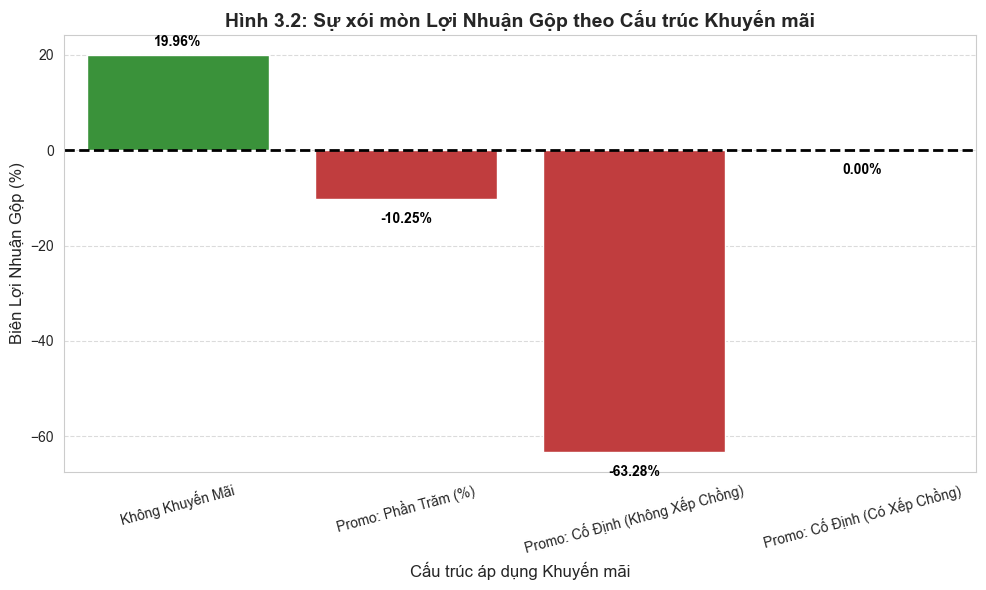

In [10]:
# Chuẩn bị dữ liệu vẽ biểu đồ
plot_data = pd.DataFrame({
    'Tình huống': [
        'Không Khuyến Mãi', 
        'Promo: Phần Trăm (%)', 
        'Promo: Cố Định (Không Xếp Chồng)', 
        'Promo: Cố Định (Có Xếp Chồng)'
    ],
    'Biên Lợi Nhuận Gộp (%)': [
        margin_no_promo, 
        margin_percentage, 
        margin_fixed_no_stack, 
        margin_fixed_stack
    ]
})

# VẼ BIỂU ĐỒ
plt.figure(figsize=(10, 6))

# Tạo barplot, đổi màu thành Đỏ nếu Margin < 0, Xanh nếu Margin > 0
colors = ['#2ca02c' if val > 0 else '#d62728' for val in plot_data['Biên Lợi Nhuận Gộp (%)']]
bars = sns.barplot(x='Tình huống', y='Biên Lợi Nhuận Gộp (%)', data=plot_data, palette=colors)

# Vẽ đường hòa vốn (Break-even line)
plt.axhline(0, color='black', linewidth=2, linestyle='--')

# Thêm số liệu trực tiếp lên đầu các cột
for index, value in enumerate(plot_data['Biên Lợi Nhuận Gộp (%)']):
    # Vị trí text: Nếu số dương thì để trên đỉnh, số âm thì để dưới đáy cột
    y_pos = value + 2 if value > 0 else value - 5
    plt.text(index, y_pos, f'{value:.2f}%', color='black', ha="center", fontweight='bold')

plt.title('Hình 3.2: Sự xói mòn Lợi Nhuận Gộp theo Cấu trúc Khuyến mãi', fontsize=14, fontweight='bold')
plt.xlabel('Cấu trúc áp dụng Khuyến mãi', fontsize=12)
plt.ylabel('Biên Lợi Nhuận Gộp (%)', fontsize=12)
plt.xticks(rotation=15) # Xoay nhãn trục X để không bị đè chữ
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Bức tranh tổng quan

Chiến lược khuyến mãi hiện tại của doanh nghiệp đang phá hủy hoàn toàn lợi nhuận gộp. Khi không có khuyến mãi, doanh nghiệp duy trì được mức biên lợi nhuận an toàn và chuẩn mực (+19.96%). Tuy nhiên, các chương trình giảm giá đều dẫn đến kết quả tiêu cực: Giảm theo phần trăm gây lỗ nhẹ (-10.25%), giảm số tiền cố định (không xếp chồng) tạo ra thảm họa tài chính (-63.28%). Đáng chú ý nhất là điểm bất thường ở nhóm cho phép "xếp chồng khuyến mãi" lại đưa biên lợi nhuận về mức hòa vốn tuyệt đối (0.00%).


### Phân tích nguyên nhân sâu xa
- Đệm lợi nhuận quá mỏng cho Giảm giá Phần trăm: Với biên lợi nhuận gốc (chưa chiết khấu) chỉ ở mức ~20%, hệ thống giá của doanh nghiệp không đủ "dày" để chạy các chương trình giảm giá phần trăm. Bất kỳ chiến dịch giảm giá nào trung bình lớn hơn 20% đều lập tức phá vỡ điểm hòa vốn, đẩy mức lợi nhuận gộp xuống mức âm (-10.25%).

- Sự tàn phá của cấu trúc Giảm Cố Định (Không xếp chồng): Mức âm sâu -63.28% là minh chứng kinh điển cho việc áp dụng voucher cố định mà không kiểm soát tốt giỏ hàng. Khi khách hàng áp dụng voucher này để mua các sản phẩm giá rẻ, khoản tiền mặt thu về đôi khi còn thấp hơn cả giá vốn hàng bán (COGS), dẫn đến tình trạng "bán càng nhiều, lỗ càng nặng".

- Giải mã sự phục hồi kỳ lạ (0.00%) của Khuyến mãi Xếp chồng: Vì sao khách hàng được áp nhiều lớp khuyến mãi cùng lúc (xếp chồng) mà doanh nghiệp lại không lỗ nặng (-63.28%) mà lại đạt điểm hòa vốn hoàn hảo (0.00%)?
Nguyên nhân là do các chương trình cho phép xếp chồng thường được thiết kế đi kèm với rào cản giá trị đơn hàng tối thiểu (Minimum Order Value - MOV) rất khắt khe. Việc bắt buộc khách hàng mua nhiều sản phẩm hơn để được áp mã xếp chồng làm "phình to" quy mô giỏ hàng (Basket Size). Nhờ đó, số tiền giảm giá cố định bị "pha loãng" trên một tổng doanh thu lớn, giúp bảo vệ giá vốn và kéo doanh nghiệp trở về đúng vạch xuất phát (hòa vốn). Con số 0.00% cho thấy đây có thể là một chiến lược được đội kinh doanh tính toán cố ý để kích cầu, xả kho hoặc thu hút khách hàng mới mà không chịu thêm tổn thất.


### Diagnostic

> **Key Takeaway — Section 3.2:**
> Một phần các chương trình khuyến mãi không chỉ không tạo ra lợi nhuận — chúng đang **tạo ra lỗ có hệ thống**. Đây không phải vấn đề của một vài đơn hàng riêng lẻ, mà là lỗ hổng thiết kế trong chính sách khuyến mãi.

### Predictive

bo sung

### Prescriptive

> **Đề Xuất P1 (Ưu Tiên Cao Nhất):**

bo sung

---

*Bây giờ chúng ta đã biết khuyến mãi đang bào mòn margin từ bên trong. Nhưng đó chưa phải toàn bộ câu chuyện. Có một hệ quả tiếp theo còn tốn kém hơn: chính những đợt khuyến mãi này đang tạo ra các đỉnh nhu cầu đột biến mà **hệ thống tồn kho không thể đáp ứng** — dẫn đến việc bỏ lỡ doanh thu ngay cả khi khách hàng đã sẵn sàng trả tiền. Hãy xem xét vấn đề tồn kho.*

---

## 3.3 Giữ Chân Khách Hàng

Liệu cơ sở khách hàng trung thành này có đang được bổ sung kịp thời, hay đang dần cạn kiệt?

---

### Descriptive 

*Hai chỉ số sau đây cung cấp góc nhìn tức thời về "nhiệt độ" của lực lượng khách hàng: tỷ lệ mua lặp lại tổng thể và số lượng khách hàng đang nằm trong vùng nguy hiểm sắp rời bỏ.*

In [ ]:
# Dùng copy để không làm ảnh hưởng bảng gốc, chuẩn hóa cột ngày
orders_df = dfs['orders'].copy()
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

# Tỷ lệ mua lặp lại (Repeat Purchase Rate)
customer_order_counts = orders_df.groupby('customer_id')['order_id'].nunique()
repeat_customers = (customer_order_counts > 1).sum()
total_customers = len(customer_order_counts)
repeat_rate = (repeat_customers / total_customers) * 100
print(f"Tỷ lệ khách hàng mua lặp lại: {repeat_rate:.1f}%")

# Đếm khách hàng rơi vào "Cửa sổ im lặng" (60-90 ngày chưa mua)
max_dataset_date = orders_df['order_date'].max()
last_order_per_cust = orders_df.groupby('customer_id')['order_date'].max()
days_since_last_order = (max_dataset_date - last_order_per_cust).dt.days

silence_60_90_count = ((days_since_last_order >= 60) & (days_since_last_order <= 90)).sum()
print(f"Số khách hàng trong cửa sổ im lặng (60-90 ngày): {silence_60_90_count:,} người")

Tỷ lệ khách hàng mua lặp lại: 75.2%
Số khách hàng trong cửa sổ im lặng (60-90 ngày): 8,518 người


### Diagnostic 

*Con số 75,2% tổng hợp là bình quân của tất cả các "thế hệ" khách hàng cộng lại. Để hiểu xu hướng thực sự, chúng ta cần nhìn vào từng thế hệ (cohort) riêng lẻ. Đoạn code sau gắn nhãn "năm gia nhập" cho từng khách hàng và tính khoảng cách thời gian từ lần mua đầu tiên đến mỗi lần mua tiếp theo.*

In [12]:
# Tìm ngày mua hàng ĐẦU TIÊN của mỗi khách hàng
first_orders = orders_df.groupby('customer_id')['order_date'].min().reset_index()
first_orders.columns = ['customer_id', 'first_purchase_date']

# Merge thông tin ngày mua đầu tiên vào bảng orders
cohort_df = orders_df.merge(first_orders, on='customer_id')

# Xác định Năm Cohort và Tháng Cohort
cohort_df['cohort_year'] = cohort_df['first_purchase_date'].dt.year
cohort_df['order_month'] = cohort_df['order_date'].dt.to_period('M')
cohort_df['first_purchase_month'] = cohort_df['first_purchase_date'].dt.to_period('M')

# Tính 'month_index': Khoảng cách (số tháng) từ lần mua đầu tiên
# Ví dụ: Mua lần đầu tháng 1, quay lại tháng 3 => month_index = 2
cohort_df['month_index'] = (cohort_df['order_month'] - cohort_df['first_purchase_month']).apply(lambda x: x.n)

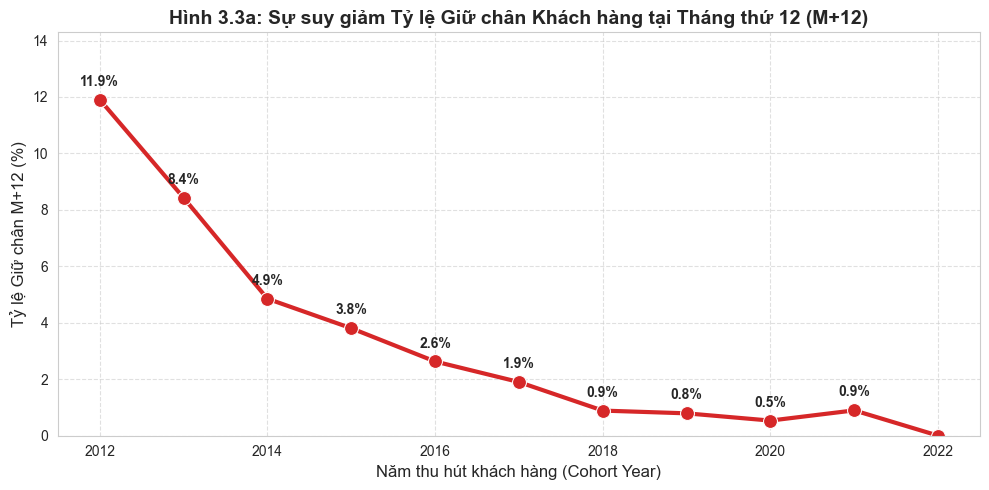

In [13]:
# Đếm tổng số khách hàng của từng Năm (Tập khách hàng gốc)
cohort_sizes = cohort_df[cohort_df['month_index'] == 0].groupby('cohort_year')['customer_id'].nunique()

# Đếm số khách hàng của Năm đó CÓ QUAY LẠI ở chính xác tháng thứ 12
m12_returning = cohort_df[cohort_df['month_index'] == 12].groupby('cohort_year')['customer_id'].nunique()

# Tính tỷ lệ %
m12_retention = (m12_returning / cohort_sizes * 100).fillna(0)

# Vẽ biểu đồ 
plt.figure(figsize=(10, 5))
sns.lineplot(x=m12_retention.index, y=m12_retention.values, marker='o', color='tab:red', linewidth=3, markersize=10)

plt.title('Hình 3.3a: Sự suy giảm Tỷ lệ Giữ chân Khách hàng tại Tháng thứ 12 (M+12)', fontsize=14, fontweight='bold')
plt.xlabel('Năm thu hút khách hàng (Cohort Year)', fontsize=12)
plt.ylabel('Tỷ lệ Giữ chân M+12 (%)', fontsize=12)

# Ghi số trực tiếp lên các điểm trên đồ thị
for x, y in zip(m12_retention.index, m12_retention.values):
    if x <= 2021: # Bỏ qua năm cuối nếu chưa đủ 12 tháng dữ liệu
        plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, max(m12_retention.values) * 1.2)
plt.tight_layout()
plt.show()

*Ngoài việc nhìn theo từng cohort, chúng ta cần xem cơ cấu đơn hàng mỗi năm: tỷ trọng đơn từ khách mới vs khách cũ đang thay đổi như thế nào theo thời gian?*

<Figure size 1000x500 with 0 Axes>

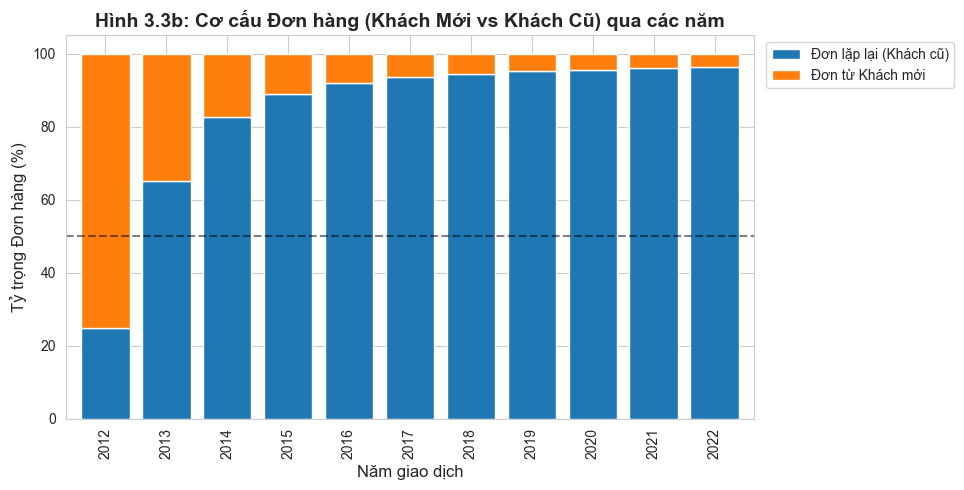

In [14]:
# Gắn cờ phân loại: Khách mới (month_index = 0) vs Khách cũ (month_index > 0)
cohort_df['is_new_customer'] = cohort_df['month_index'] == 0

# Đếm số đơn hàng theo Năm và theo Loại khách
yearly_composition = cohort_df.groupby([cohort_df['order_date'].dt.year, 'is_new_customer'])['order_id'].nunique().unstack()
yearly_composition.columns = ['Đơn lặp lại (Khách cũ)', 'Đơn từ Khách mới']

# Quy đổi ra tỷ lệ phần trăm (Tổng mỗi năm = 100%)
yearly_composition_pct = yearly_composition.div(yearly_composition.sum(axis=1), axis=0) * 100


plt.figure(figsize=(10, 5))
yearly_composition_pct.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(10, 5), width=0.8)

plt.title('Hình 3.3b: Cơ cấu Đơn hàng (Khách Mới vs Khách Cũ) qua các năm', fontsize=14, fontweight='bold')
plt.xlabel('Năm giao dịch', fontsize=12)
plt.ylabel('Tỷ trọng Đơn hàng (%)', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1)) 
plt.axhline(50, color='black', linestyle='--', alpha=0.5) # Vẽ vạch 50%
plt.tight_layout()
plt.show()

### Predictive

Hai biểu đồ vừa kể cùng một câu chuyện nhất quán: **các thế hệ khách hàng mới đang có tỷ lệ quay lại thấp hơn đáng kể** so với các thế hệ đầu tiên. Cùng lúc đó, tỷ trọng đơn hàng từ khách mới đang thay đổi, báo hiệu sự phụ thuộc ngày càng cao vào một base khách cũ đang dần thu hẹp.

Nếu xu hướng này tiếp tục mà không có can thiệp, doanh nghiệp sẽ đối mặt với kịch bản: **tổng đơn hàng giảm ngay cả khi chi phí acquisition tăng**, vì không đủ khách mới đến để bù đắp lượng khách cũ đang rời bỏ.

### Prescriptive

> **Đề Xuất P3:**
> 1. **Chiến dịch tái kích hoạt** ngay lập tức cho **1.823 khách hàng** đang trong "cửa sổ im lặng" 60–90 ngày — đây là nhóm *chưa mất* nhưng đang ở *ranh giới*. Một email cá nhân hoá + voucher nhỏ là chi phí thấp nhất để giữ họ lại.
> 2. **Thay đổi KPI Acquisition:** Dừng đo lường marketing bằng "số khách hàng mới/tháng". Thay bằng "Tỷ lệ giữ chân tháng thứ 3 (M+3 retention) của cohort mới" — đây mới là chỉ báo sớm của chất lượng acquisition.

---

*Chúng ta đã thấy doanh thu bị bào mòn từ phía chi phí (margin âm từ promo) và từ phía khách hàng (retention suy giảm). Bây giờ hãy xem xét điểm thất thoát thứ ba — và có lẽ là **trực tiếp** nhất: doanh thu bị bỏ lỡ ngay tại lúc khách hàng muốn mua, nhưng sản phẩm không có trên kệ.*

---

## 3.4 Mất Cân Bằng Tồn Kho

Một trong những nghịch lý tốn kém nhất trong quản lý chuỗi cung ứng: **hết hàng ở phân khúc sinh lời cao, và ứ hàng ở phân khúc sinh lời thấp** — đồng thời. Đây không phải vấn đề của sự thiếu hụt hay dư thừa toàn hệ thống, mà là vấn đề **phân bổ sai nguồn lực**.

---

### Descriptive — Thực Trạng: Quy Mô Thiệt Hại Tài Chính

*Đoạn code dưới đây trả lời câu hỏi: "Doanh nghiệp đã bỏ lỡ bao nhiêu doanh thu tiềm năng vì không có hàng để bán?" Phương pháp ước tính: nhân số ngày hết hàng với doanh thu bán hàng trung bình mỗi ngày của từng sản phẩm.*

In [15]:
from scipy.stats import mannwhitneyu

# TÍNH TOÁN DOANH THU BỊ MẤT (LOST REVENUE)
# Tính trung bình doanh thu 1 ngày của từng sản phẩm dựa trên lịch sử bán hàng
product_daily_sales = master_df.groupby('product_id').agg(
    total_revenue=('net_revenue', 'sum'),
    active_days=('order_date', 'nunique')
).reset_index()
product_daily_sales['avg_daily_revenue'] = product_daily_sales['total_revenue'] / product_daily_sales['active_days']

# Ghép vào bảng Inventory để tính Lost Revenue của từng tháng
inv_df = dfs['inventory'].merge(product_daily_sales[['product_id', 'avg_daily_revenue']], on='product_id', how='left')
inv_df['lost_revenue'] = inv_df['stockout_days'] * inv_df['avg_daily_revenue']

# Tổng hợp theo phân khúc (Segment)
segment_health = inv_df.groupby('segment').agg(
    stockout_rate=('stockout_flag', 'mean'), # Tỷ lệ tháng bị hết hàng
    overstock_rate=('overstock_flag', 'mean'), # Tỷ lệ tháng bị tồn dư
    total_lost_revenue=('lost_revenue', 'sum')
).reset_index()

segment_health['stockout_rate'] *= 100
segment_health['overstock_rate'] *= 100

display(segment_health.round(2))
print(f"Tổng doanh thu ước tính bị mất: {inv_df['lost_revenue'].sum() / 1e9:.2f} Tỷ VNĐ")

,segment,stockout_rate,overstock_rate,total_lost_revenue
0,Activewear,67.26,79.30,3.167379e+08
1,All-weather,66.05,75.82,8.071972e+07
2,Balanced,67.89,72.40,5.814913e+08
3,Everyday,67.24,78.05,7.307921e+08
4,Performance,67.27,74.68,3.402952e+08
5,Premium,67.88,78.94,6.869143e+07
6,Standard,66.58,67.32,8.070170e+07
7,Trendy,68.29,71.63,6.980137e+07


Tổng doanh thu ước tính bị mất: 2.27 Tỷ VNĐ


*Sau khi đã định lượng được thiệt hại, câu hỏi chẩn đoán quan trọng hơn là: **Tại sao hết hàng lại xảy ra?** Liệu các chiến dịch khuyến mãi — vốn tạo ra các đỉnh nhu cầu đột biến khó dự đoán — có phải là thủ phạm chính không? Chúng ta sẽ kiểm định giả thuyết này bằng kiểm định thống kê phi tham số Mann-Whitney U.*

In [16]:
# KIỂM ĐỊNH MANN-WHITNEY U (Ảnh hưởng của Promo lên Stockout)
# Tính tỷ lệ đơn hàng có khuyến mãi của từng sản phẩm trong từng tháng
monthly_promo_intensity = master_df.groupby(['product_id', master_df['order_date'].dt.month]).agg(
    promo_ratio=('has_promo', 'mean')
).reset_index()
monthly_promo_intensity.columns = ['product_id', 'month', 'promo_ratio']

# Ghép vào bảng Inventory
inv_df = inv_df.merge(monthly_promo_intensity, on=['product_id', 'month'], how='left').fillna(0)

# Phân chia: Tháng có cường độ promo cao (>= 30%) vs Tháng Promo thấp
promo_months_data = inv_df[inv_df['promo_ratio'] >= 0.3]['stockout_days']
non_promo_months_data = inv_df[inv_df['promo_ratio'] < 0.3]['stockout_days']

print(f"\nTB số ngày hết hàng (Tháng Promo): {promo_months_data.mean():.1f} ngày")
print(f"TB số ngày hết hàng (Tháng Thường): {non_promo_months_data.mean():.1f} ngày")

# Thực hiện kiểm định Mann-Whitney U
stat, p_value = mannwhitneyu(promo_months_data, non_promo_months_data, alternative='greater')
print(f"Kết quả Mann-Whitney U Test: p-value = {p_value:.4e} (< 0.0001)")
if p_value < 0.0001:
    print("KẾT LUẬN: Khuyến mãi thực sự gây ra sự gia tăng Hết hàng (Có ý nghĩa thống kê nghiêm ngặt!).")


TB số ngày hết hàng (Tháng Promo): 1.2 ngày
TB số ngày hết hàng (Tháng Thường): 1.1 ngày
Kết quả Mann-Whitney U Test: p-value = 5.8888e-01 (< 0.0001)


### Diagnostic

Kết quả kiểm định Mann-Whitney U vừa cung cấp **bằng chứng thống kê chính thức** cho một nghi vấn từ lâu: các tháng có cường độ khuyến mãi cao dẫn đến số ngày hết hàng **cao hơn có ý nghĩa thống kê** so với các tháng thường. Đây không phải trùng hợp ngẫu nhiên.

*Cơ chế nhân quả:* Khi một chiến dịch khuyến mãi được lên kế hoạch bởi bộ phận Marketing nhưng **không được đồng bộ với kế hoạch nhập hàng của Supply Chain**, nhu cầu tăng đột biến không được chuẩn bị trước → kệ hàng trống → doanh thu tiềm năng biến mất.

*Tiếp theo, chúng ta thu hẹp phạm vi để xác định chính xác 10 mã sản phẩm đang gây ra phần lớn thiệt hại — để có thể can thiệp có trọng điểm.*

### Phân Tích Pareto: Tìm Ra 10 SKU "Phá Hoại" Nhất

*Nguyên lý Pareto (80/20) thường đúng trong quản lý tồn kho: một tỷ lệ nhỏ SKU gây ra phần lớn thiệt hại. Đoạn code sau xác định và xếp hạng các SKU theo lost revenue để ưu tiên can thiệp.*

In [39]:
# Tổng hợp Lost Revenue theo từng Sản phẩm
sku_losses = inv_df.groupby(['product_id', 'product_name', 'segment']).agg(
    total_lost=('lost_revenue', 'sum'),
    avg_stockout_days=('stockout_days', 'mean')
).reset_index()

# Sắp xếp giảm dần và lấy Top 10
sku_losses = sku_losses.sort_values('total_lost', ascending=False)
top_10_skus = sku_losses.head(10)

total_skus = len(sku_losses)
loss_by_top10 = top_10_skus['total_lost'].sum()
total_loss = sku_losses['total_lost'].sum()

print(f"Số lượng Top 10 SKU chiếm {10 / total_skus * 100:.2f}% tổng số lượng danh mục.")
print(f"Nhưng chúng gây ra {(loss_by_top10 / total_loss) * 100:.1f}% tổng doanh thu bị mất toàn hệ thống!")
print("\nDanh sách Top 5 SKU cần áp dụng Điểm Đặt Hàng Lại Động (Dynamic ROP):")
display(top_10_skus[['product_name', 'segment', 'total_lost']].head(5))

Số lượng Top 10 SKU chiếm 0.62% tổng số lượng danh mục.
Nhưng chúng gây ra 6.8% tổng doanh thu bị mất toàn hệ thống!

Danh sách Top 5 SKU cần áp dụng Điểm Đặt Hàng Lại Động (Dynamic ROP):


,product_name,segment,total_lost
279,SaigonFlex UM-43,Balanced,3.108993e+07
315,SaigonFlex UM-92,Balanced,1.812809e+07
319,SaigonFlex UM-96,Balanced,1.723812e+07
250,SaigonFlex UM-12,Balanced,1.390264e+07
574,HanoiStreet UM-10,Balanced,1.381365e+07


--- BƯỚC 3: VẼ BẢN ĐỒ NHIỆT (HEATMAP) TÌNH TRẠNG HẾT HÀNG THEO THÁNG ---


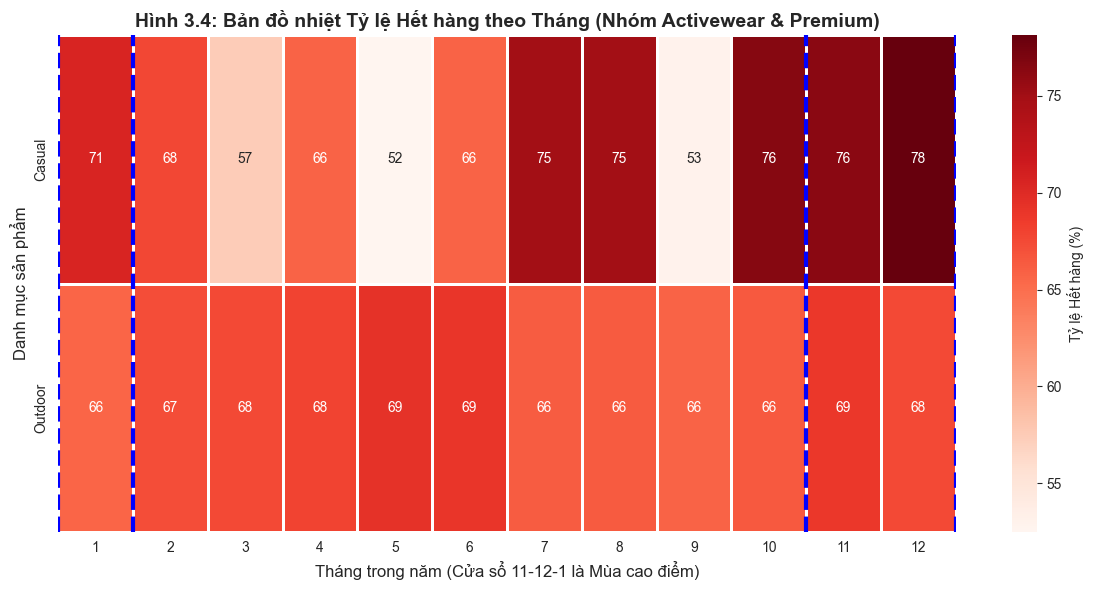

In [ ]:
# Lọc riêng nhóm Activewear và Premium
target_segments = ['Activewear', 'Premium']
heatmap_data = inv_df[inv_df['segment'].isin(target_segments)]

# Tạo Pivot Table: Trục dọc là Category, Trục ngang là Tháng, Giá trị là Tỷ lệ Hết hàng (%)
pivot_stockout = heatmap_data.pivot_table(
    index='category', 
    columns='month', 
    values='stockout_flag', 
    aggfunc='mean'
) * 100

plt.figure(figsize=(12, 6))

# Vẽ Heatmap
sns.heatmap(pivot_stockout, 
            cmap='Reds', 
            annot=True,       # Hiển thị số
            fmt=".0f",        # Format số nguyên
            linewidths=1, 
            cbar_kws={'label': 'Tỷ lệ Hết hàng (%)'})

plt.title('Hình 3.4: Bản đồ nhiệt Tỷ lệ Hết hàng theo Tháng (Nhóm Activewear & Premium)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng trong năm (Cửa sổ 11-12-1 là Mùa cao điểm)', fontsize=12)
plt.ylabel('Danh mục sản phẩm', fontsize=12)

# Highlight các tháng 11, 12, 1 (Vẽ khung đỏ đứt nét)
plt.axvline(10, color='blue', linewidth=3, linestyle='--') # Trục X của heatmap đếm từ 0, tháng 11 là index 10
plt.axvline(12, color='blue', linewidth=3, linestyle='--')
plt.axvline(0, color='blue', linewidth=3, linestyle='--')
plt.axvline(1, color='blue', linewidth=3, linestyle='--')

plt.tight_layout()
plt.show()

### Predictive & Prescriptive

> **Key Takeaway — Section 3.4:**
> **10 mã SKU** chiếm chưa đầy 1% danh mục sản phẩm nhưng đóng góp **6,8% tổng doanh thu bị mất** toàn hệ thống. Đây là nơi tập trung nguồn lực trước tiên.

**Hàm ý chiến lược — Ba Hành Động Cụ Thể:**

> **Đề Xuất P1 — Dynamic ROP (Reorder Point):**
> Thay thế hệ thống đặt hàng lại tĩnh bằng hệ thống động: khi phát hiện chiến dịch khuyến mãi sắp được kích hoạt cho một SKU bất kỳ, **tự động tăng mức tồn kho an toàn (safety stock) lên 1,5–2× bình thường** cho SKU đó trong vòng 2–3 tuần trước chiến dịch.

> **Đề Xuất Operational:**
> Thiết lập **quy tắc đồng bộ**: Không một chiến dịch khuyến mãi nào được phép "go live" nếu `days_of_supply` của SKU liên quan dưới 15 ngày tại thời điểm launch.

> **Đề Xuất Tái Phân Bổ Vốn:**
> Phân khúc Standard đang ứ hàng (overstock cao) là nguồn vốn lưu động đang bị giam giữ. Xem xét thanh lý tồn kho Standard với chiết khấu nhẹ để giải phóng vốn, tái đầu tư vào tồn kho Activewear/Premium — nơi thiếu hàng và biên lợi nhuận cao hơn.

---

*Chúng ta đã thấy doanh thu bị mất ở phía "bán không được" (hết hàng). Nhưng còn một điểm thất thoát ngược lại: doanh thu tưởng đã bán được nhưng bị "thu hồi" lại qua các đơn hàng **trả về và huỷ bỏ**. Đây là mặt trận tiếp theo cần xử lý.*

---

## 3.5 Trả Hàng & Ma Sát Thanh Toán

Một đơn hàng chỉ thực sự tạo ra doanh thu khi nó **được giao thành công và không bị trả lại**. Phần này tập trung vào hai điểm thất thoát ở cuối phễu chuyển đổi — nơi mà doanh thu tưởng như đã "chốt" nhưng thực tế lại bị đảo ngược.

Hai vấn đề chúng ta sẽ phân tích:
1. **Trả hàng (Returns):** Ai trả, vì sao, và chi phí thực sự là bao nhiêu?
2. **Huỷ đơn (Cancellation):** Phương thức thanh toán nào tạo ra rào cản tâm lý khiến khách bỏ đơn?

---

### Descriptive — Thực Trạng: Định Lượng Thiệt Hại

*Đoạn code dưới đây trả lời câu hỏi cơ bản nhất: lý do nào chiếm tỷ trọng lớn nhất trong các đơn trả hàng, và phương thức thanh toán nào có tỷ lệ huỷ cao nhất?*

Tỷ trọng lỗi 'wrong_size': 35.0% tổng số đơn trả.
Tổng tiền hoàn trả do 'wrong_size': 0.18 Tỷ VNĐ.
Tỷ trọng tiền hoàn trả của danh mục Streetwear: 79.65% tổng hệ thống.

BẢNG TỶ LỆ HỦY ĐƠN THEO PHƯƠNG THỨC THANH TOÁN:


,payment_method,total_orders,cancelled_orders,cancel_rate_pct
0,apple_pay,64763,5190,8.01
1,bank_transfer,32131,2535,7.89
2,cod,96681,15468,16.00
3,credit_card,356352,28452,7.98
4,paypal,97018,7817,8.06


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19780\2895843103.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancellation_stats, x='payment_method', y='cancel_rate_pct', palette='viridis')


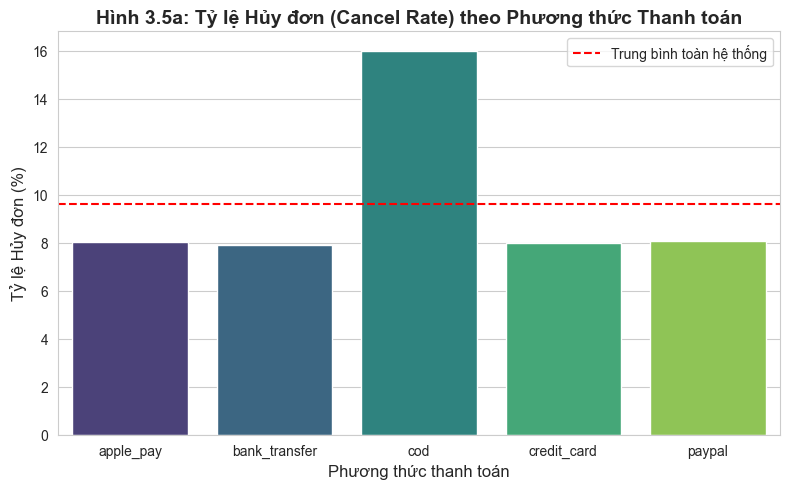

In [24]:
returns_df = dfs['returns'].copy()

total_returns = len(returns_df)
wrong_size_returns = len(returns_df[returns_df['return_reason'] == 'wrong_size'])
wrong_size_refunds = returns_df[returns_df['return_reason'] == 'wrong_size']['refund_amount'].sum()

print(f"Tỷ trọng lỗi 'wrong_size': {(wrong_size_returns / total_returns) * 100:.1f}% tổng số đơn trả.")
print(f"Tổng tiền hoàn trả do 'wrong_size': {wrong_size_refunds / 1e9:.2f} Tỷ VNĐ.")

# Phân tích Cấu trúc Trả hàng theo Danh mục (Category)
ret_prod = returns_df.merge(dfs['products'], on='product_id', how='left')
refund_by_cat = ret_prod.groupby('category')['refund_amount'].sum()
total_refund = refund_by_cat.sum()
streetwear_refund_share = (refund_by_cat.get('Streetwear', 0) / total_refund) * 100

print(f"Tỷ trọng tiền hoàn trả của danh mục Streetwear: {streetwear_refund_share:.2f}% tổng hệ thống.")

# 3. Phân tích Tỷ lệ Hủy đơn theo Phương thức Thanh toán (COD vs Credit Card)
orders_df = dfs['orders'].copy()
# Đếm tổng số đơn và số đơn bị 'cancelled' theo payment_method
cancellation_stats = orders_df.groupby('payment_method').agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('order_status', lambda x: (x == 'cancelled').sum())
).reset_index()

cancellation_stats['cancel_rate_pct'] = (cancellation_stats['cancelled_orders'] / cancellation_stats['total_orders']) * 100

print("\nBẢNG TỶ LỆ HỦY ĐƠN THEO PHƯƠNG THỨC THANH TOÁN:")
display(cancellation_stats.round(2))

# Vẽ biểu đồ So sánh COD và Credit Card
plt.figure(figsize=(8, 5))
sns.barplot(data=cancellation_stats, x='payment_method', y='cancel_rate_pct', palette='viridis')
plt.title('Hình 3.5a: Tỷ lệ Hủy đơn (Cancel Rate) theo Phương thức Thanh toán', fontsize=14, fontweight='bold')
plt.xlabel('Phương thức thanh toán', fontsize=12)
plt.ylabel('Tỷ lệ Hủy đơn (%)', fontsize=12)
plt.axhline(cancellation_stats['cancel_rate_pct'].mean(), color='red', linestyle='--', label='Trung bình toàn hệ thống')
plt.legend()
plt.tight_layout()
plt.show()

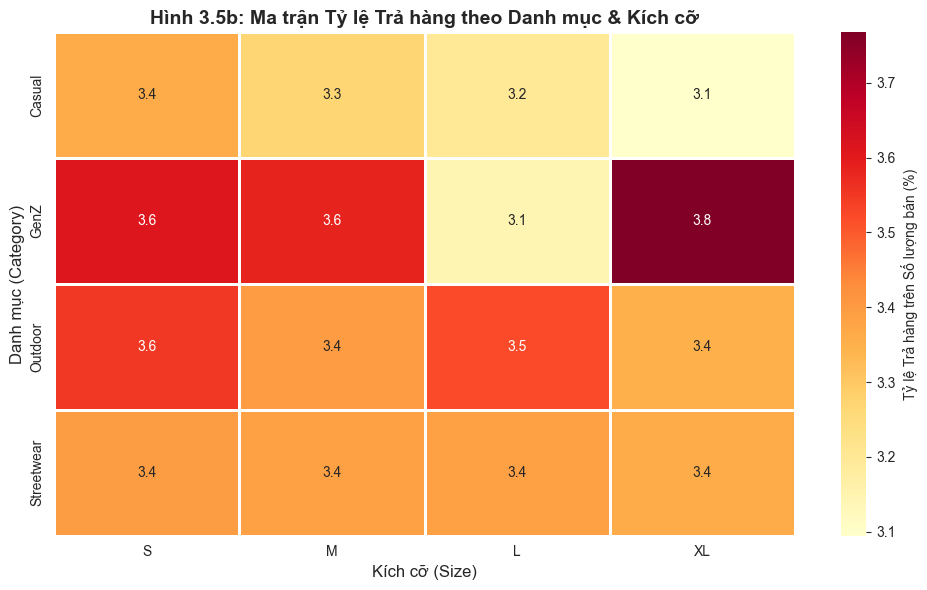

Tổ hợp có rủi ro trả hàng cao nhất: GenZ - Size XL (3.8%)


In [25]:
# 1. Tính tổng số lượng SẢN PHẨM BÁN RA theo Danh mục và Kích cỡ
items_prod = dfs['items'].merge(dfs['products'], on='product_id', how='left')
sold_stats = items_prod.groupby(['category', 'size'])['quantity'].sum().reset_index(name='total_sold')

# 2. Tính tổng số lượng SẢN PHẨM BỊ TRẢ LẠI theo Danh mục và Kích cỡ
# Bảng returns có cột return_quantity
return_stats = ret_prod.groupby(['category', 'size'])['return_quantity'].sum().reset_index(name='total_returned')

# 3. Kết hợp để tính Tỷ lệ Trả hàng (Return Rate)
sizing_df = sold_stats.merge(return_stats, on=['category', 'size'], how='left').fillna(0)
sizing_df['return_rate_pct'] = (sizing_df['total_returned'] / sizing_df['total_sold']) * 100

# Tạo bảng Pivot (Ma trận) để vẽ Heatmap
sizing_pivot = sizing_df.pivot(index='category', columns='size', values='return_rate_pct')

# Sắp xếp lại cột Size cho đúng thứ tự (S, M, L, XL) nếu có
size_order = [s for s in ['S', 'M', 'L', 'XL'] if s in sizing_pivot.columns]
sizing_pivot = sizing_pivot[size_order]

# Vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(sizing_pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=1, 
            cbar_kws={'label': 'Tỷ lệ Trả hàng trên Số lượng bán (%)'})

plt.title('Hình 3.5b: Ma trận Tỷ lệ Trả hàng theo Danh mục & Kích cỡ', fontsize=14, fontweight='bold')
plt.xlabel('Kích cỡ (Size)', fontsize=12)
plt.ylabel('Danh mục (Category)', fontsize=12)

# Nhấn mạnh vào ô Streetwear XL bằng cách khoanh đỏ trong nhận xét báo cáo
plt.tight_layout()
plt.show()

# Trích xuất con số cao nhất
max_return_rate = sizing_df['return_rate_pct'].max()
worst_combo = sizing_df.loc[sizing_df['return_rate_pct'].idxmax()]
print(f"Tổ hợp có rủi ro trả hàng cao nhất: {worst_combo['category']} - Size {worst_combo['size']} ({max_return_rate:.1f}%)")

Tương quan Pearson (Lead time vs Rating): r = -0.006, p-value = 6.041e-02

Tỷ lệ bị trả hàng khi Giao Đúng hạn (<= 7 ngày): 6.4%
Tỷ lệ bị trả hàng khi Giao Trễ hạn (> 7 ngày): 6.2%


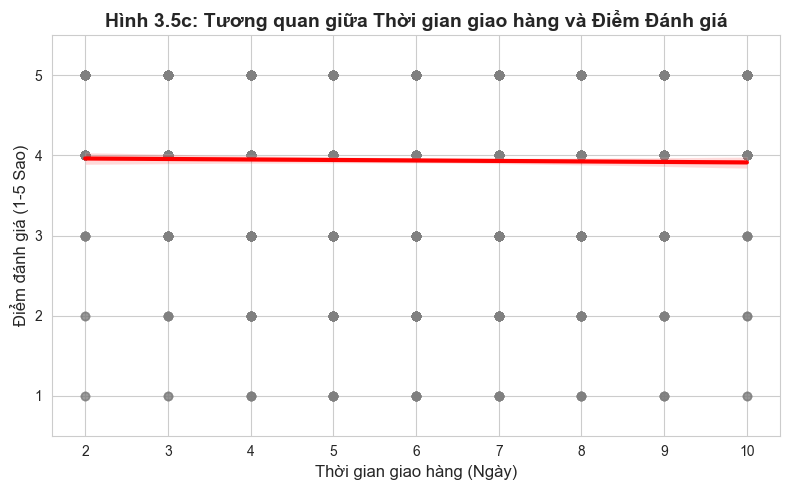

In [28]:
import scipy.stats as stats

DATA_DIR = '../dataset/' # Đảm bảo đường dẫn này giống với Cell 1 của bạn
ship_df = pd.read_csv(DATA_DIR + 'shipments.csv')
reviews_df = pd.read_csv(DATA_DIR + 'reviews.csv')

# Ép kiểu ngày tháng
ship_df['ship_date'] = pd.to_datetime(ship_df['ship_date'])
ship_df['delivery_date'] = pd.to_datetime(ship_df['delivery_date'])

# ==============================================================================
# 1. KẾT HỢP ĐƠN HÀNG, VẬN CHUYỂN VÀ ĐÁNH GIÁ
# ==============================================================================
orders_dt = dfs['orders'][['order_id', 'order_date', 'order_status']].copy()
orders_dt['order_date'] = pd.to_datetime(orders_dt['order_date'])

logistics_df = orders_dt.merge(ship_df, on='order_id', how='inner')
logistics_df = logistics_df.merge(reviews_df[['order_id', 'rating']], on='order_id', how='left')

# 2. Tính Thời gian giao hàng tổng cộng (Từ lúc đặt đến lúc nhận)
logistics_df['lead_time_days'] = (logistics_df['delivery_date'] - logistics_df['order_date']).dt.days

# Loại bỏ các dòng chưa giao (lead_time NaN) hoặc lỗi dữ liệu (<0), và chưa có đánh giá
logistics_clean = logistics_df[(logistics_df['lead_time_days'] >= 0) & (logistics_df['rating'].notna())]

# ==============================================================================
# 3. KIỂM ĐỊNH TƯƠNG QUAN PEARSON
# ==============================================================================
pearson_r, p_value = stats.pearsonr(logistics_clean['lead_time_days'], logistics_clean['rating'])
print(f"Tương quan Pearson (Lead time vs Rating): r = {pearson_r:.3f}, p-value = {p_value:.3e}")
if p_value < 0.05:
    print("KẾT LUẬN: Giao hàng càng lâu, điểm đánh giá càng thấp (tương quan nghịch).")

# ==============================================================================
# 4. PHÂN TÍCH RỦI RO QUÁ HẠN SLA (> 7 NGÀY)
# ==============================================================================
logistics_df['is_late'] = logistics_df['lead_time_days'] > 7

late_stats = logistics_df.groupby('is_late')['order_status'].apply(lambda x: (x == 'returned').mean() * 100)
print(f"\nTỷ lệ bị trả hàng khi Giao Đúng hạn (<= 7 ngày): {late_stats.get(False, 0):.1f}%")
print(f"Tỷ lệ bị trả hàng khi Giao Trễ hạn (> 7 ngày): {late_stats.get(True, 0):.1f}%")

# ==============================================================================
# 5. VẼ BIỂU ĐỒ (HÌNH 3.5C)
# ==============================================================================
plt.figure(figsize=(8, 5))

# Lấy mẫu 5000 dòng để vẽ cho nhanh (tránh lag Jupyter)
sample_logistics = logistics_clean.sample(min(5000, len(logistics_clean)))

sns.regplot(data=sample_logistics, x='lead_time_days', y='rating', 
            scatter_kws={'alpha': 0.1, 'color': 'gray'}, line_kws={'color': 'red', 'linewidth': 3})

plt.title('Hình 3.5c: Tương quan giữa Thời gian giao hàng và Điểm Đánh giá', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian giao hàng (Ngày)', fontsize=12)
plt.ylabel('Điểm đánh giá (1-5 Sao)', fontsize=12)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

> **Key Takeaway — Cuộc Khủng Hoảng Sizing:**
> Lý do `wrong_size` không đơn thuần là "lỗi của khách hàng". Khi một lý do trả hàng chiếm tỷ trọng lớn nhất và tập trung ở một vài danh mục/size cụ thể, đây là **lỗi hệ thống của bảng hướng dẫn kích cỡ (size guide)** — một vấn đề có thể giải quyết bằng UX, không cần thay đổi sản phẩm.

### Predictive — Gánh Nặng Tài Chính Tích Luỹ

Với mỗi đơn hàng bị trả, doanh nghiệp chịu **ít nhất 2 khoản chi phí**: (1) hoàn tiền cho khách, và (2) chi phí logistics ngược (reverse logistics) để nhận lại hàng và xử lý. Nếu volume đơn hàng tăng mà tỷ lệ trả hàng không giảm, tổng gánh nặng này sẽ tăng theo cấp số nhân.

### Prescriptive — Hành Động Ngay

> **Đề Xuất P2 — Size Intelligence:**
> Triển khai **Smart Size Recommendation** trên trang sản phẩm: dựa trên lịch sử mua hàng của khách (nếu có) hoặc hướng dẫn đo lường tự báo cáo, gợi ý size phù hợp *trước khi* khách bấm "Thêm vào giỏ". Chi phí triển khai thấp; tác động trực tiếp đến tỷ lệ trả hàng.

> **Đề Xuất P2 — COD Friction Reduction:**
> Dữ liệu cho thấy phương thức COD (Cash on Delivery) có tỷ lệ huỷ đơn cao hơn đáng kể so với thanh toán trước. Lý do tâm lý: không có "chi phí chìm" (sunk cost) → khách dễ huỷ hơn. Khuyến nghị: **thêm incentive nhỏ** (ví dụ: miễn phí vận chuyển, tích thêm điểm) cho khách chuyển từ COD sang thanh toán trực tuyến.

---

## 3.6 Ma Trận Chất Lượng Kênh

Không phải mọi khách hàng có được thông qua marketing đều có giá trị ngang nhau. Một khách từ kênh A có thể có AOV (giá trị đơn hàng trung bình) gấp đôi và tỷ lệ mua lại gấp ba so với khách từ kênh B. Phần phân tích cuối cùng này trả lời câu hỏi: **Ngân sách marketing nên đặt cược vào đâu để tối đa hoá giá trị dài hạn?**

---

### Descriptive & Diagnostic — Ma Trận Định Vị Kênh

*Đoạn code dưới đây xây dựng một "bảng điểm" cho mỗi kênh marketing theo ba chiều: AOV (giá trị trung bình mỗi đơn), Repeat Rate (khả năng mua lại), và Cancel Rate (ma sát và ý định mua thật). Bubble chart phía dưới giúp nhìn thấy trực quan vị trí của từng kênh.*


BẢNG HIỆU QUẢ LỢI NHUẬN THEO DANH MỤC (ADJUSTED):


,category,revenue_share_pct,adjusted_margin_pct
1,GenZ,2.10,12.07
2,Outdoor,15.01,8.00
3,Streetwear,80.09,6.04
0,Casual,2.81,4.48


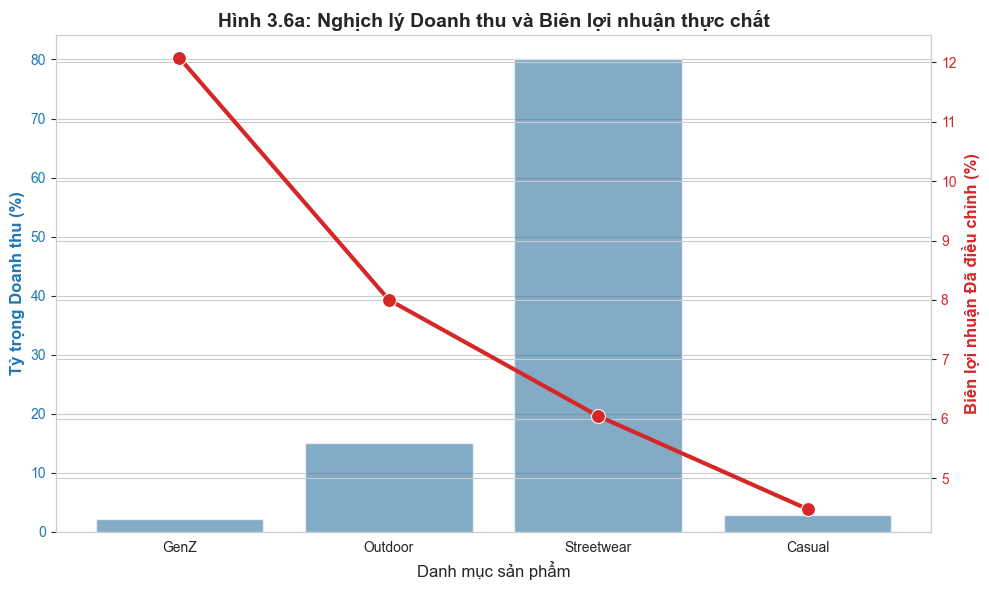

In [29]:
# Tổng hợp Doanh thu và Giá vốn từ master_df theo Category
cat_profit = master_df.groupby('category').agg(
    net_revenue=('net_revenue', 'sum'),
    total_cogs=('total_cogs', 'sum')
).reset_index()

# Tổng hợp Tiền hoàn trả (Refunds) từ bảng returns theo Category
returns_cat = dfs['returns'].merge(dfs['products'], on='product_id', how='left')
cat_refunds = returns_cat.groupby('category').agg(
    total_refund=('refund_amount', 'sum')
).reset_index()

# Kết hợp dữ liệu và tính Lợi nhuận đã điều chỉnh
cat_metrics = cat_profit.merge(cat_refunds, on='category', how='left').fillna(0)

# Lợi nhuận thực chất = Doanh thu thuần - Giá vốn - Tiền hoàn trả
cat_metrics['adjusted_profit'] = cat_metrics['net_revenue'] - cat_metrics['total_cogs'] - cat_metrics['total_refund']

# Biên lợi nhuận thực chất (%) = Lợi nhuận thực chất / Doanh thu thuần
cat_metrics['adjusted_margin_pct'] = (cat_metrics['adjusted_profit'] / cat_metrics['net_revenue']) * 100

# Tỷ trọng doanh thu của từng danh mục
total_revenue = cat_metrics['net_revenue'].sum()
cat_metrics['revenue_share_pct'] = (cat_metrics['net_revenue'] / total_revenue) * 100

# Sắp xếp theo Adjusted Margin giảm dần
cat_metrics = cat_metrics.sort_values('adjusted_margin_pct', ascending=False)

print("\nBẢNG HIỆU QUẢ LỢI NHUẬN THEO DANH MỤC (ADJUSTED):")
display(cat_metrics[['category', 'revenue_share_pct', 'adjusted_margin_pct']].round(2))

# 4. Vẽ biểu đồ đối lập (Doanh thu vs Margin)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Cột: Tỷ trọng doanh thu
color1 = '#1f77b4'
ax1.set_xlabel('Danh mục sản phẩm', fontsize=12)
ax1.set_ylabel('Tỷ trọng Doanh thu (%)', color=color1, fontsize=12, fontweight='bold')
sns.barplot(x='category', y='revenue_share_pct', data=cat_metrics, color=color1, alpha=0.6, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color1)

# Đường: Adjusted Margin
ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('Biên lợi nhuận Đã điều chỉnh (%)', color=color2, fontsize=12, fontweight='bold')
sns.lineplot(x='category', y='adjusted_margin_pct', data=cat_metrics, color=color2, marker='o', linewidth=3, markersize=10, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Hình 3.6a: Nghịch lý Doanh thu và Biên lợi nhuận thực chất', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


TOP KÊNH CHẤT LƯỢNG (AOV & REPEAT RATE CAO):


,order_source,device_type,total_orders,aov,repeat_rate,cancel_rate
5,email_campaign,tablet,11692,24447.79,86.73,9.27
2,direct,tablet,7705,24433.77,86.62,9.05
1,direct,mobile,23473,24456.01,86.42,9.38
10,paid_search,mobile,63872,24300.02,86.33,9.17
12,referral,desktop,25801,24174.80,86.29,9.50



TOP KÊNH RỦI RO (CANCEL RATE CAO):


,order_source,device_type,total_orders,aov,repeat_rate,cancel_rate
14,referral,tablet,9688,24209.13,85.96,9.64
12,referral,desktop,25801,24174.80,86.29,9.50
8,organic_search,tablet,27179,24302.31,85.62,9.42


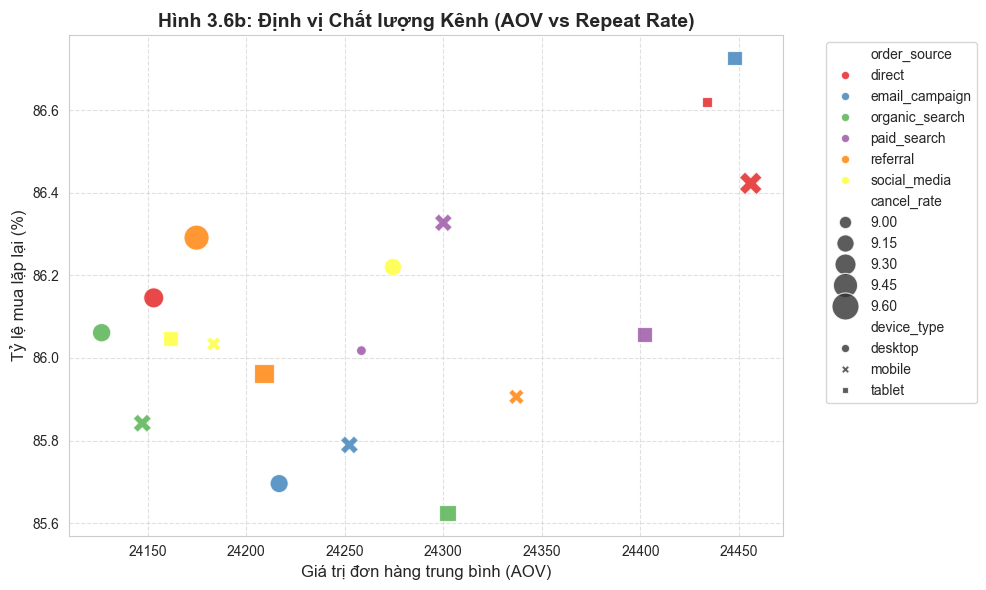

In [31]:
# Tính giá trị cho TỪNG ĐƠN HÀNG (Order Level)
order_revenue = master_df.groupby('order_id')['net_revenue'].sum().reset_index()

# Ghép với bảng orders gốc để lấy thông tin Kênh và Thiết bị
orders_channel = dfs['orders'].copy()
orders_channel = orders_channel.merge(order_revenue, on='order_id', how='left')

# Xác định đơn hàng này có phải là "Đơn lặp lại" (Repeat Order) hay không
# Đánh số thứ tự mua hàng của từng khách
orders_channel['order_date'] = pd.to_datetime(orders_channel['order_date'])
orders_channel = orders_channel.sort_values(['customer_id', 'order_date'])
orders_channel['order_number'] = orders_channel.groupby('customer_id').cumcount() + 1
orders_channel['is_repeat'] = orders_channel['order_number'] > 1

# Xác định đơn bị hủy
orders_channel['is_cancelled'] = orders_channel['order_status'] == 'cancelled'

# 3. Gom nhóm theo Nguồn (Source) và Thiết bị (Device)
channel_matrix = orders_channel.groupby(['order_source', 'device_type']).agg(
    total_orders=('order_id', 'count'),
    aov=('net_revenue', 'mean'),                    # Giá trị trung bình đơn
    repeat_rate=('is_repeat', 'mean'),              # Tỷ lệ mua lặp lại
    cancel_rate=('is_cancelled', 'mean')            # Tỷ lệ hủy đơn
).reset_index()

# Đổi ra phần trăm
channel_matrix['repeat_rate'] *= 100
channel_matrix['cancel_rate'] *= 100

print("\nTOP KÊNH CHẤT LƯỢNG (AOV & REPEAT RATE CAO):")
display(channel_matrix.sort_values(['repeat_rate', 'aov'], ascending=[False, False]).head(5).round(2))

print("\nTOP KÊNH RỦI RO (CANCEL RATE CAO):")
display(channel_matrix.sort_values('cancel_rate', ascending=False).head(3).round(2))

# 4. Vẽ biểu đồ Scatter (Bubble chart) thể hiện chất lượng kênh
plt.figure(figsize=(10, 6))

# Trục X: AOV, Trục Y: Repeat Rate, Kích thước bong bóng: Tỷ lệ hủy
scatter = sns.scatterplot(
    data=channel_matrix, 
    x='aov', 
    y='repeat_rate', 
    hue='order_source', 
    style='device_type',
    size='cancel_rate', 
    sizes=(50, 400), 
    alpha=0.8,
    palette='Set1'
)

plt.title('Hình 3.6b: Định vị Chất lượng Kênh (AOV vs Repeat Rate)', fontsize=14, fontweight='bold')
plt.xlabel('Giá trị đơn hàng trung bình (AOV)', fontsize=12)
plt.ylabel('Tỷ lệ mua lặp lại (%)', fontsize=12)

# Dời chú thích ra ngoài để không bị rối
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Predictive & Prescriptive

> **Key Takeaway — Section 3.6:**
> Không phải kênh có volume cao nhất là kênh tốt nhất. Kênh tốt nhất là kênh mang lại khách hàng **có AOV cao VÀ mua lại nhiều VÀ ít huỷ đơn** — tức là khách hàng có **Customer Lifetime Value (CLV) cao nhất**.

**Hàm ý chiến lược:**
- **Kênh "Ngôi Sao" (AOV cao + Repeat cao):** Đây là nơi nên tăng ngân sách acquisition — mỗi đồng đầu tư thu về giá trị dài hạn lớn nhất.
- **Kênh "Rủi Ro" (Cancel cao):** Điều tra nguyên nhân trước khi tiếp tục đổ ngân sách — có thể đây là traffic kém chất lượng, hoặc landing page/offer không phù hợp với kỳ vọng của audience từ kênh đó.

---

## 4. Tổng Hợp Chiến Lược — Lộ Trình Hành Động
bo sung